# Análisis Exploratorio de Datos de Ventas en E-commerce

# Autor: Eduardo Ferré Valderrama


## Introducción

Este notebook realiza un análisis exploratorio de datos (EDA) sobre un conjunto de datos de ventas en un e-commerce. El objetivo es explorar las características de los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

El dataset contiene información sobre transacciones de ventas, incluyendo detalles del cliente, productos comprados, precios y fechas de compra. El análisis se centra en la identificación de tendencias de ventas, segmentación de clientes y análisis de productos.

Se utilizan bibliotecas como pandas, numpy, matplotlib y seaborn para la manipulación y visualización de datos. El análisis incluye la limpieza de datos, la exploración de variables, la identificación de valores atípicos y la creación de visualizaciones para comprender mejor los patrones en los datos.


## Importación de librerías y carga de datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv("../data/ecommerce-dataset.csv")

## Vista preliminar e inspección general


In [2]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_method       51290 non-null 

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


Se inspecciona la estructura del dataset para entender cuántas columnas y registros tiene, así como los tipos de datos.

El dataset contiene **51.290 registros** y **16 columnas** que describen distintos aspectos de transacciones en una tienda online: datos del cliente (`Customer_Id`, `Gender`, `Device_Type`), del producto (`Product`, `Product_Category`, `Sales`, `Quantity`, etc.), y de la orden (`Order_Date`, `Time`, `Order_Priority`, `Payment_method`, etc.).

Observamos que las columnas `Order_Date` y `Time` están en formato `object`, por lo que se deberán convertir a formatos de fecha y hora (`datetime`) para facilitar análisis temporales.


## Análisis de valores nulos


In [3]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

Se detectaron valores nulos en 6 columnas, pero representaban menos del 0.01% del dataset. Por ello, se optará por eliminar las filas correspondientes para mantener la integridad del análisis sin afectar la muestra.


In [4]:
df.isnull()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Limpieza de datos


In [5]:
# Eliminamos duplicados 
df.drop_duplicates(inplace=True)

# Eliminamos filas con valores nulos
df.dropna(inplace=True)

# Convertimos fechas
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time


Se eliminan posibles filas duplicadas y aquellas que contienen valores nulos. También se realiza la conversión de los campos `Order_Date` y `Time` al formato adecuado, lo que permitirá agrupar por día, mes, año, o analizar el comportamiento horario.


## Análisis exploratorio de datos (EDA)


In [203]:
custom_palette = [
    '#064B9F',  # Más oscuro 
    '#0669BF',  # Azul oscuro
    '#0D8FD4',  # Azul medio
    '#0D9FD9',  # Azul vibrante
    '#11C5D9',  # Celeste
    '#5DCEAC',  # Verde-agua
    '#7BD96C',  # Verde claro
    '#62BF1F',  # Verde lima
    '#51A117',  # Verde musgo suave 
    '#3C8C14'   # Verde más profundo 
]



### Ventas Generales


In [204]:
# Total de ventas ($)
total_sales = df['Sales'].sum()
total_units = df['Quantity'].sum()

print(f"Total de ventas: ${total_sales:,.2f}")
print(f"Total de unidades vendidas: {int(total_units)}")


Total de ventas: $7,812,164.00
Total de unidades vendidas: 128357


El total de ventas registradas en el período es de aproximadamente **$7,812,164**, con un total de **128357 unidades vendidas**.

Ahora analizaremos cómo se distribuyen esas ventas a lo largo del tiempo.


#### Ventas por mes


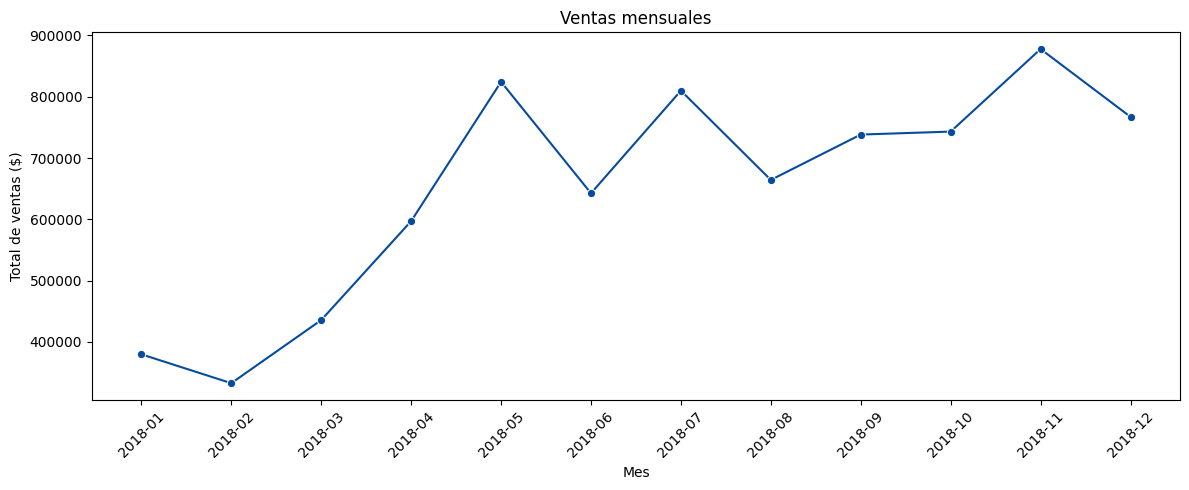

In [205]:
df['Order_Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Order_Month')['Sales'].sum().reset_index()
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', marker='o', color=custom_palette[0])
plt.xticks(rotation=45)
plt.title('Ventas mensuales')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


#### Ventas por día de la semana y hora


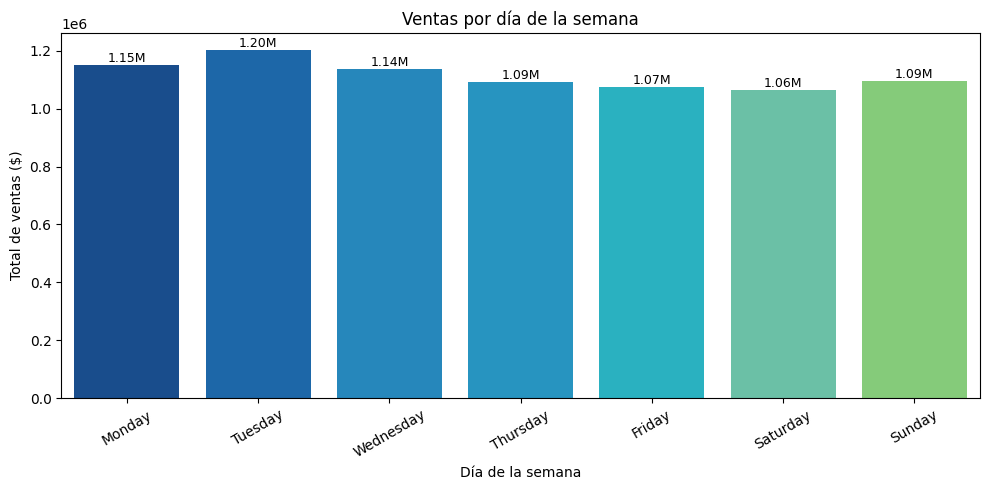

In [226]:
df['Weekday'] = df['Order_Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

weekdays_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Ventas por día de la semana

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df,                     
    x='Weekday',                
    y='Sales',                  
    estimator=sum,               
    order=weekdays_order,        
    palette = custom_palette,   # Habría que ver si es conveniente usar alguna paleta o dejar todo en azul        
    ci='sd'                     
)

plt.title('Ventas por día de la semana')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Día de la semana')
plt.xticks(rotation=30)

for p in ax.patches:  # Itera sobre cada barra
    height = p.get_height()  # Obtiene la altura (valor de ventas)
    ax.annotate(
        f'{height/1e6:.2f}M',                       # Formatea el número en millones (ej. 1.20M)
        (p.get_x() + p.get_width() / 2, height),    # Posición: centro de la barra, arriba del valor
        ha='center', va='bottom', fontsize=9, color='black'  # Ajustes estéticos
    )


plt.tight_layout()
plt.show()

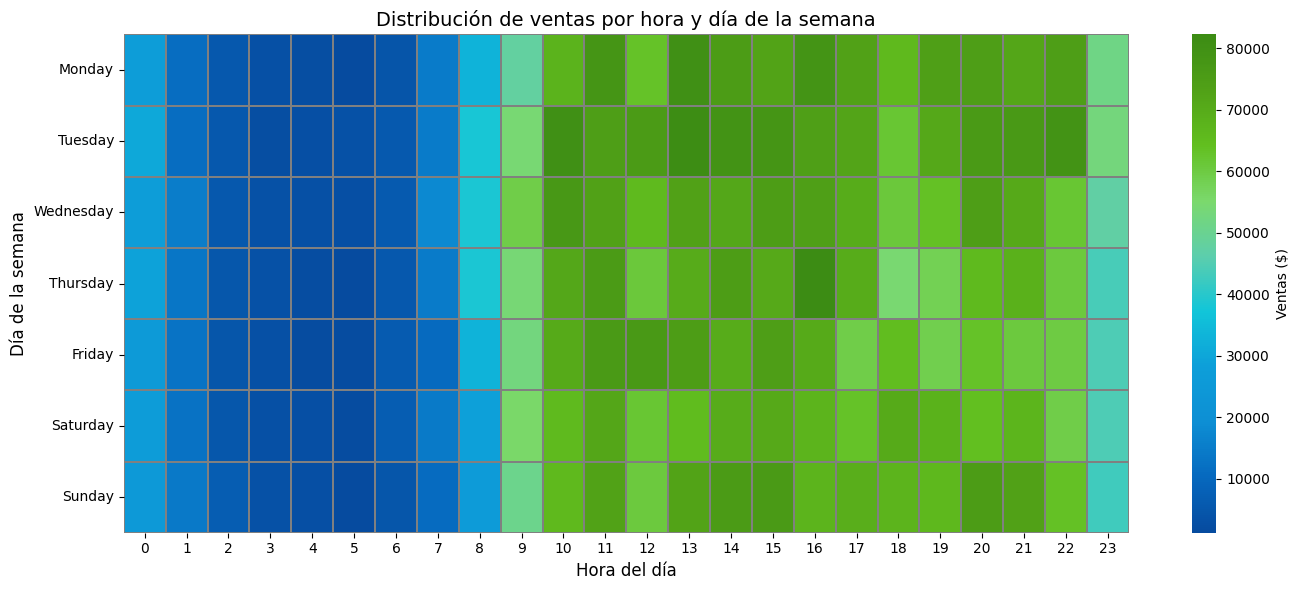

In [246]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list("custom", custom_palette)

# Heatmap de hora vs día
pivot = df.pivot_table(
    values='Sales',  
    index='Weekday',  
    columns='Hour',  
    aggfunc='sum'     
)

pivot = pivot.reindex(weekdays_order)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,                    
    cmap=custom_cmap,           
    linewidths=0.3,           
    linecolor='gray',         
    cbar_kws={'label': 'Ventas ($)'}  
)

plt.title('Distribución de ventas por hora y día de la semana', fontsize=14)
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Día de la semana', fontsize=12)
plt.tight_layout() # Ajustar márgenes automáticamente
plt.show()         


### Productos


#### Top 10 productos más vendidos


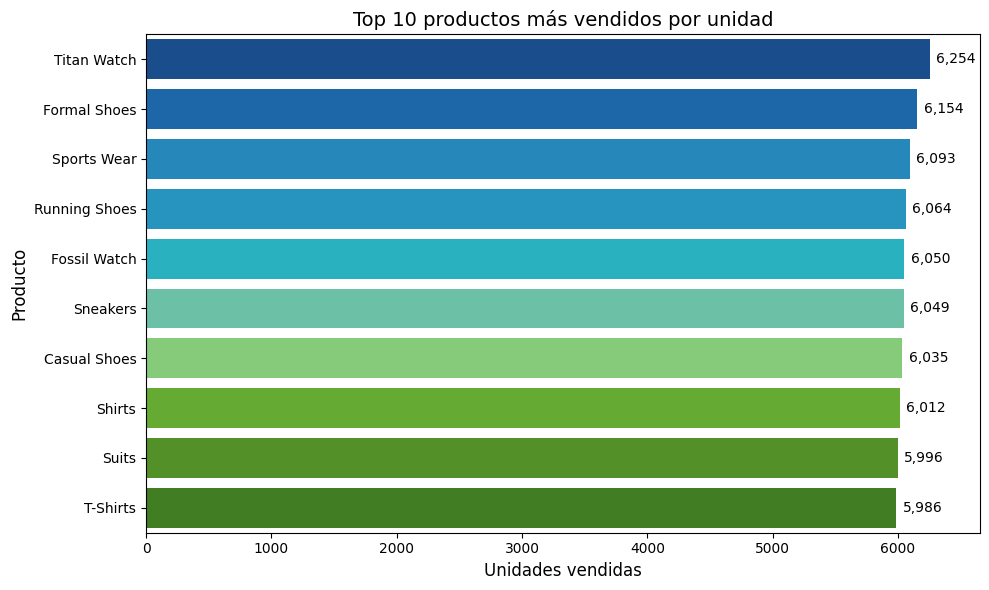

In [265]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

# Es correcto esto?
top_products.index = top_products.index.str.replace('Titak watch', 'Titan Watch')
top_products.index = top_products.index.str.replace('Casula Shoes', 'Casual Shoes')
top_products.index = top_products.index.str.replace('T - Shirts', 'T-Shirts')


plt.figure(figsize=(10, 6)) 

# Gráfico de barras horizontales
ax = sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette=custom_palette 
)

plt.title('Top 10 productos más vendidos por unidad', fontsize=14)
plt.xlabel('Unidades vendidas', fontsize=12)
plt.ylabel('Producto', fontsize=12)

# Agregar anotaciones al final de cada barra
for i, (value, label) in enumerate(zip(top_products.values, top_products.index)):
    ax.text(value + 50, i, f'{value:,.0f}', va='center', fontsize=10, color='black') # 50 es un pequeño espacio

plt.xlim(0, top_products.max() + 400)

plt.tight_layout()
plt.show()

Los productos más vendidos se identifican según la suma total de unidades. Esto permite detectar artículos populares que generan alto volumen de ventas, independientemente de su precio.


#### Productos más rentables


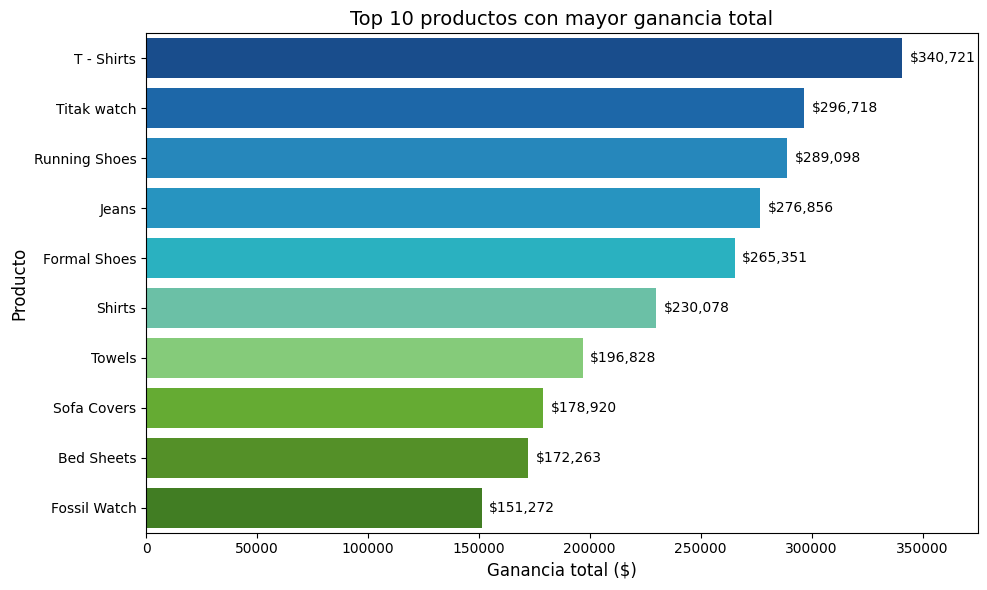

In [283]:
# Rentabilidad = suma total del Profit por producto
profitable_products = df.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(10)

top_products.index = top_products.index.str.replace('Titak watch', 'Titan Watch')
top_products.index = top_products.index.str.replace('Casula Shoes', 'Casual Shoes')
top_products.index = top_products.index.str.replace('T - Shirts', 'T-Shirts')

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=profitable_products.values,
    y=profitable_products.index,
    palette=custom_palette
)

plt.title('Top 10 productos con mayor ganancia total', fontsize=14)
plt.xlabel('Ganancia total ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)

# Agregar anotaciones con los valores de ganancia
for i, (value, label) in enumerate(zip(profitable_products.values, profitable_products.index)):
    ax.text(value + abs(profitable_products.max()) * 0.01, i, f'${value:,.0f}', 
            va='center', fontsize=10, color='white' if value < 0 else 'black')

plt.xlim(0, profitable_products.max() * 1.1)
plt.tight_layout()
plt.show()


Aquí se identifican los productos que generan mayor ganancia total. Es útil para detectar cuáles aportan más al margen de beneficio, más allá del volumen vendido.


#### Productos con y sin descuentos


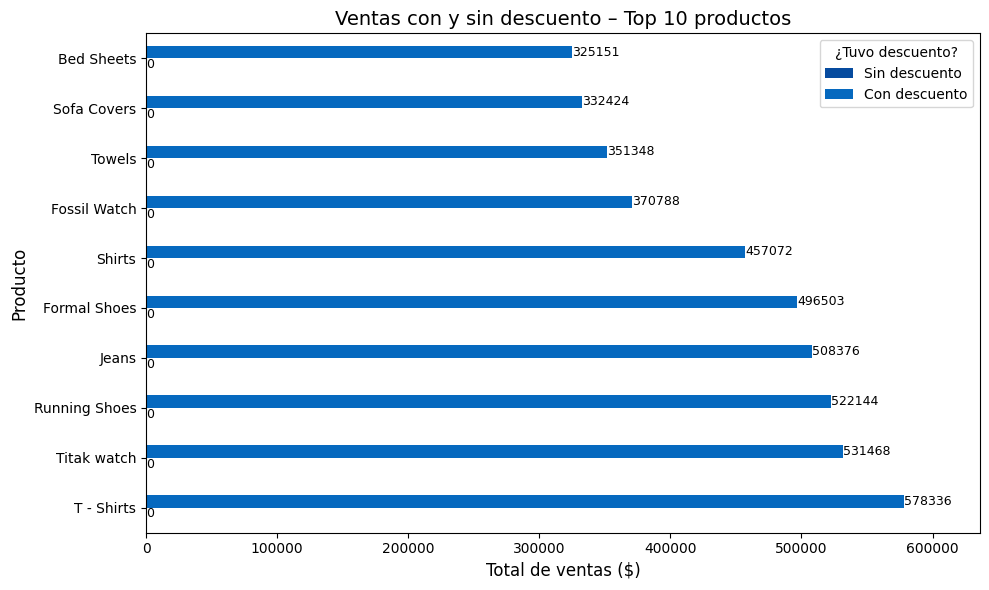

In [414]:
# Crear columna booleana para detectar descuento
df['Has_Discount'] = df['Discount'] > 0

# Agrupar ventas por producto y por condición de descuento
discount_summary = df.groupby(['Product', 'Has_Discount'])['Sales'].sum().unstack().fillna(0)

# Renombrar columnas para mayor claridad
if discount_summary.columns.tolist() == [False, True]:
    discount_summary.columns = ['Sin descuento', 'Con descuento']
elif discount_summary.columns.tolist() == [True, False]:
    discount_summary.columns = ['Con descuento', 'Sin descuento']
elif discount_summary.columns.tolist() == [True]:
    discount_summary.columns = ['Con descuento']
    discount_summary['Sin descuento'] = 0
elif discount_summary.columns.tolist() == [False]:
    discount_summary.columns = ['Sin descuento']
    discount_summary['Con descuento'] = 0
else:
    raise ValueError("Las columnas no son las esperadas.")

# Asegurar orden correcto
discount_summary = discount_summary[['Sin descuento', 'Con descuento']]

# Agregar columna total para ordenar por ventas totales
discount_summary['Total'] = discount_summary.sum(axis=1)

# Tomar top 10 productos por ventas totales
sample = discount_summary.sort_values('Total', ascending=False).drop(columns='Total').head(10)

# Gráfico de barras horizontales agrupadas
ax = sample.plot(
    kind='barh',
    stacked=False,
    figsize=(10, 6),
    color=custom_palette[:sample.shape[1]]
)

# Título y etiquetas
plt.title('Ventas con y sin descuento – Top 10 productos', fontsize=14)
plt.xlabel('Total de ventas ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.legend(title='¿Tuvo descuento?', fontsize=10)

# Etiquetas numéricas sobre cada barra y que no se salga del gráfico
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f', label_type='edge', fontsize=9, color='black')

plt.xlim(0, sample.sum(axis=1).max() * 1.1)
plt.tight_layout()
plt.show()


### Categorías


#### Ventas totales por categoría


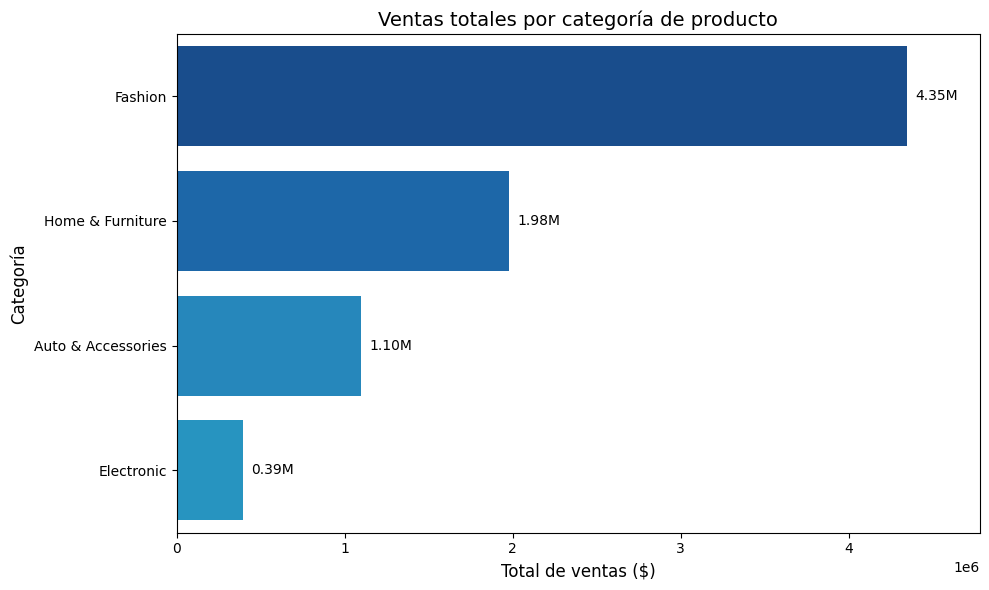

In [430]:

category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    palette=custom_palette
)

plt.title('Ventas totales por categoría de producto', fontsize=14)
plt.xlabel('Total de ventas ($)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Anotaciones al final de cada barra (en millones)
for i, (value, label) in enumerate(zip(category_sales.values, category_sales.index)):
    ax.text(value + 50_000, i, f'{value/1e6:.2f}M', va='center', fontsize=10, color='black')

plt.xlim(0, category_sales.max() * 1.1)

plt.tight_layout()
plt.show()



Este gráfico muestra el volumen de ventas por categoría de producto. Permite identificar qué rubros concentran la mayor facturación.


#### Ticket promedio por categoría


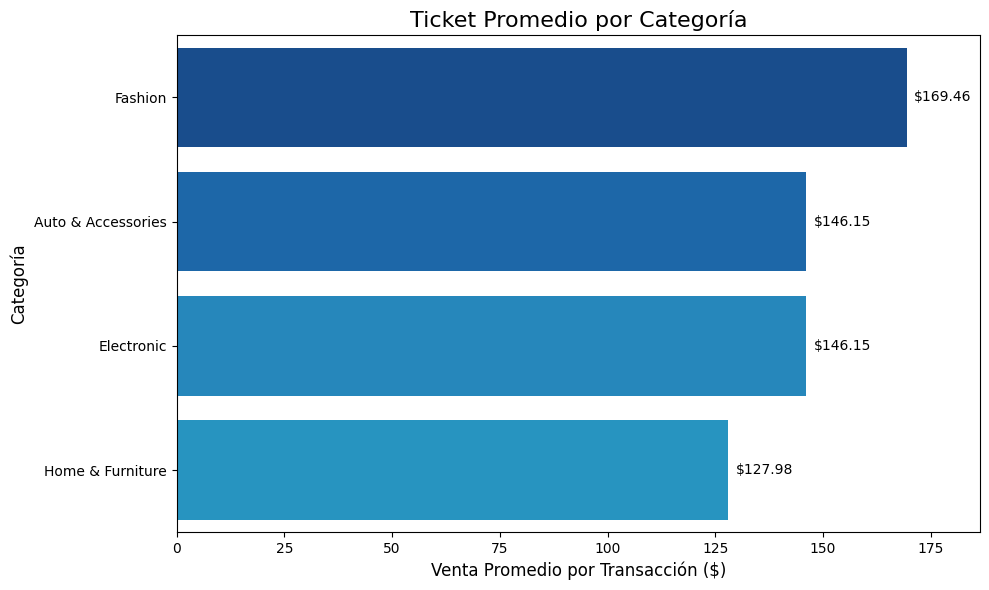

In [445]:
# Calcular ticket promedio por categoría
avg_ticket = df.groupby('Product_Category')['Sales'].mean().sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=avg_ticket.values,
    y=avg_ticket.index,
    palette=custom_palette
)

# Título y etiquetas
plt.title('Ticket Promedio por Categoría', fontsize=16)
plt.xlabel('Venta Promedio por Transacción ($)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Añadir etiquetas de valor al final de cada barra
for i, value in enumerate(avg_ticket.values):
    ax.text(
        value + avg_ticket.max() * 0.01,
        i,
        f"${value:,.2f}",
        va='center',
        fontsize=10
    )


plt.xlim(0, avg_ticket.max() * 1.1)

plt.tight_layout()
plt.show()


El ticket promedio por categoría nos indica cuánto gasta un cliente, en promedio, por transacción en cada tipo de producto.


#### Productos más vendidos dentro de cada categoría


In [446]:
top_in_cat = (
    df.groupby(['Product_Category', 'Product'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Product_Category', 'Quantity'], ascending=[True, False])
)

top3 = top_in_cat.groupby('Product_Category', group_keys=False).head(3)

top3


,Product_Category,Product,Quantity
2,Auto & Accessories,Car Body Covers,2040.0
5,Auto & Accessories,Car Pillow & Neck Rest,2012.0
8,Auto & Accessories,Tyre,2010.0
18,Electronic,Speakers,581.0
10,Electronic,Fans,523.0
17,Electronic,Samsung Mobile,501.0
31,Fashion,Titak watch,6254.0
22,Fashion,Formal Shoes,6154.0
28,Fashion,Sports Wear,6093.0
33,Home & Furniture,Beds,3908.0


En esta tabla se identifican los productos más vendidos dentro de cada categoría. Puede servir para optimizar el stock y promociones por segmento.


#### Distribución por género y categoría


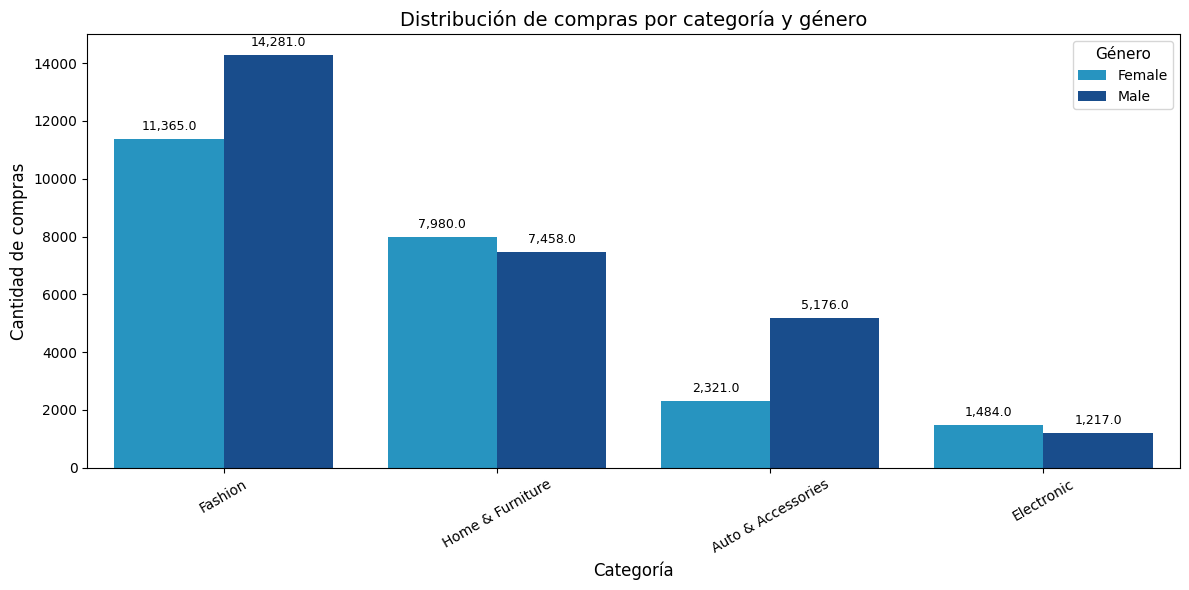

In [659]:
plt.figure(figsize=(12, 6))

palette = {
    'Female': custom_palette[3],  
    'Male': custom_palette[0]  
}

ax = sns.countplot(
    data=df,
    x='Product_Category',
    hue='Gender',
    order=category_sales.index,
    palette=palette
)

plt.title('Distribución de compras por categoría y género', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de compras', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Género', fontsize=10, title_fontsize=11)

# Anotaciones sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 200,
            f'{height:,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


Este gráfico permite ver si hay diferencias en el comportamiento de compra por género en cada categoría. Puede ser útil para personalizar campañas de marketing.


### Clientes


#### Clientes que más compran


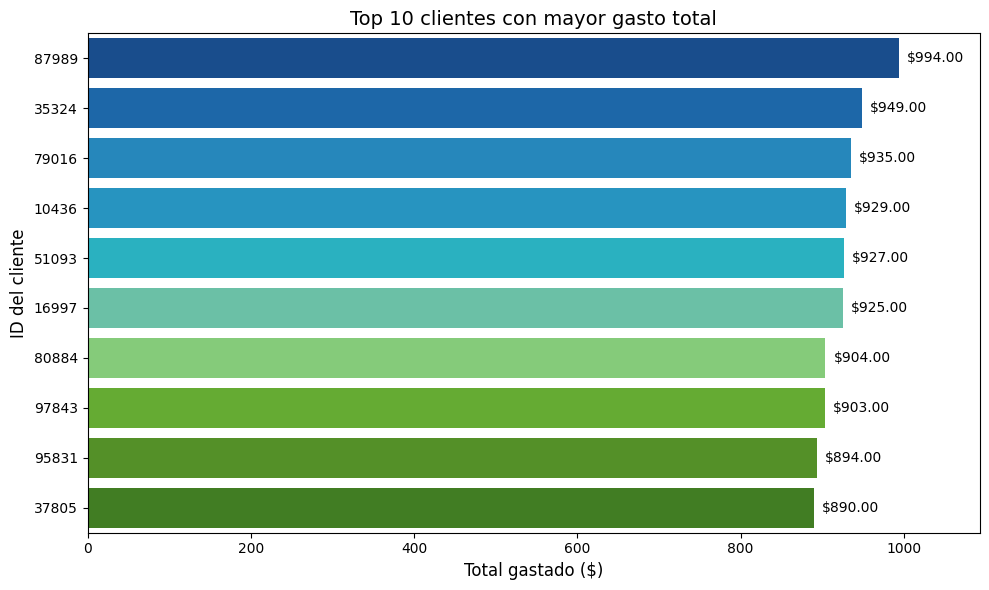

In [660]:
# Agrupar por cliente
top_clients = df.groupby('Customer_Id')['Sales'].sum().sort_values(ascending=False).head(10)

# (Opcional) Acortar el ID
top_clients.index = top_clients.index.astype(str).str[-6:]

# Se podría agrupar por el nombre, pero el dataset no presenta una tabla clientes, o el nombre de estos

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_clients.values,
    y=top_clients.index,
    palette=custom_palette
)

plt.title('Top 10 clientes con mayor gasto total', fontsize=14)
plt.xlabel('Total gastado ($)', fontsize=12)
plt.ylabel('ID del cliente', fontsize=12)

# Mostrar etiquetas de valores al final de cada barra
for i, (value, label) in enumerate(zip(top_clients.values, top_clients.index)):
    ax.text(value + top_clients.max() * 0.01, i, f'${value:,.2f}', va='center', fontsize=10, color='black')


plt.xlim(0, top_clients.max() * 1.1)
plt.tight_layout()
plt.show()

Este gráfico muestra los 10 clientes que más dinero han gastado en el ecommerce. Son candidatos ideales para campañas de fidelización o programas de beneficios.


#### Ticket promedio por cliente


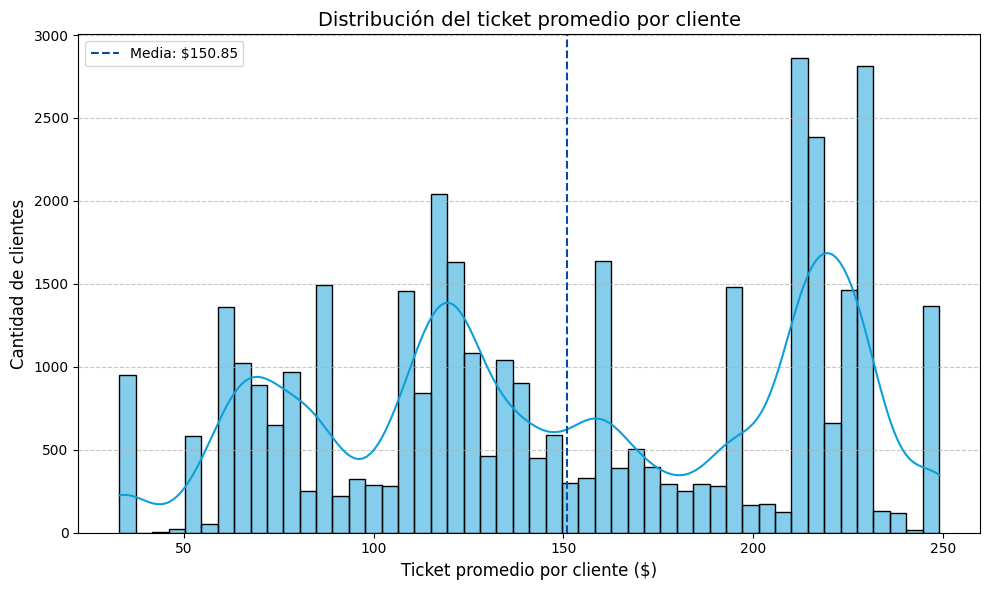

In [661]:
# Calcular ticket promedio por cliente
avg_ticket_client = df.groupby('Customer_Id')['Sales'].mean()

# Eliminar el 1% más alto para mejor visualización
filtered = avg_ticket_client[avg_ticket_client < avg_ticket_client.quantile(0.99)]
mean_ticket = filtered.mean()

plt.figure(figsize=(10, 6))

# Histograma con densidad
sns.histplot(filtered, bins=50, kde=True, color=custom_palette[3])

# Línea de media
plt.axvline(mean_ticket, color=custom_palette[0], linestyle='--', label=f'Media: ${mean_ticket:,.2f}')

# Títulos y etiquetas
plt.title('Distribución del ticket promedio por cliente', fontsize=14)
plt.xlabel('Ticket promedio por cliente ($)', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Analizando el ticket promedio por cliente se puede observar qué tan alto o bajo es el gasto por transacción. Esto puede sugerir estrategias de upselling o bundles para ciertos segmentos.


#### Frecuencia de compra por cliente


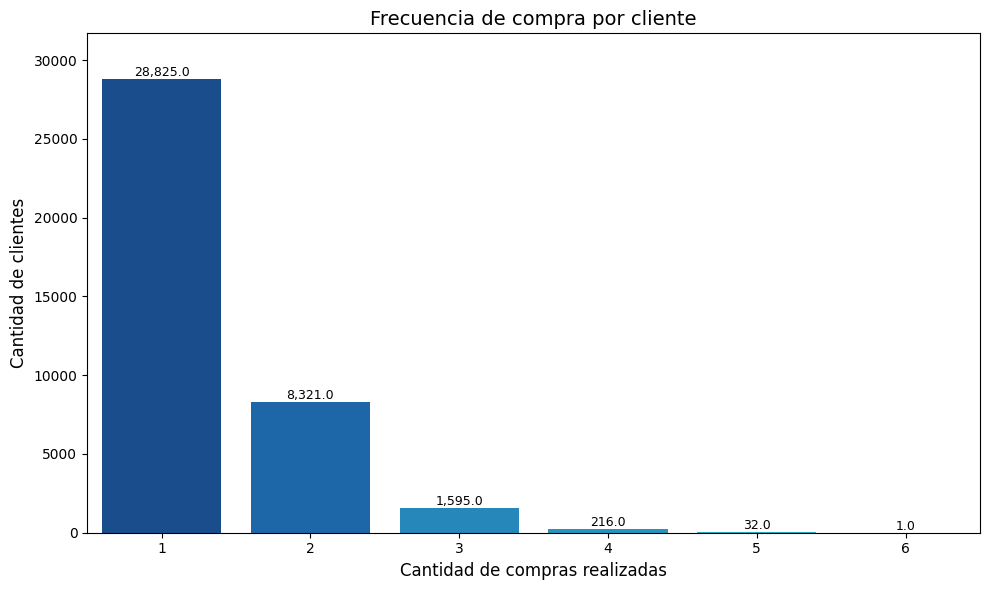

In [662]:
# Calcular cuántas compras hizo cada cliente
freq_client = df['Customer_Id'].value_counts()

plt.figure(figsize=(10, 6))

# Gráfico de barras con countplot (valores discretos)
ax = sns.countplot(
    x=freq_client,
    palette=custom_palette
)

plt.title('Frecuencia de compra por cliente', fontsize=14)
plt.xlabel('Cantidad de compras realizadas', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)

# Anotaciones sobre cada barra

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.5,
            f'{height:,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.ylim(0, freq_client.value_counts().max() * 1.1)
plt.tight_layout()
plt.show()


Este gráfico muestra cuántas veces compra cada cliente. Un cliente frecuente puede ser más valioso que uno con un ticket promedio alto pero con pocas compras.


#### Tipo de inicio de sesión: Guest vs Member


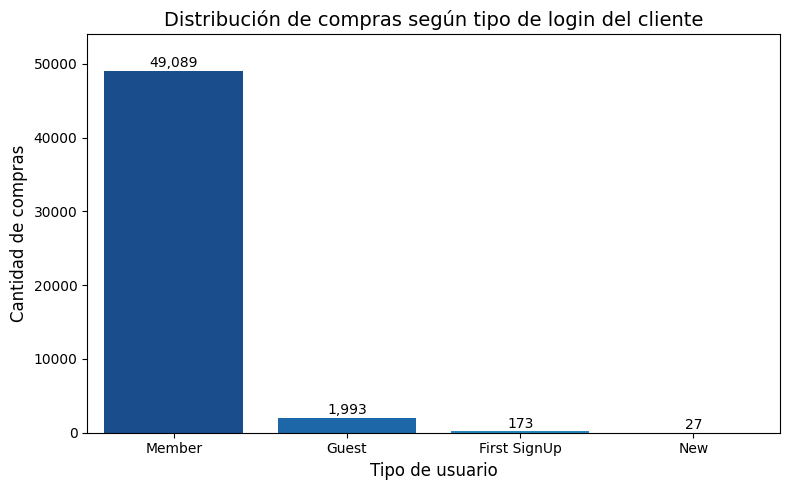

In [663]:
login_counts = df['Customer_Login_type'].value_counts()

# Ordenar categorías manualmente si es necesario
order = ['Member', 'Guest', 'First SignUp', 'New']  

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=login_counts.index,
    y=login_counts.values,
    order=order,
    palette=custom_palette  
)

plt.title('Distribución de compras según tipo de login del cliente', fontsize=14)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de compras', fontsize=12)

# Anotar valores en cada barra
for i, (value, label) in enumerate(zip(login_counts.values, login_counts.index)):
    ax.text(i, value + login_counts.max() * 0.01, f'{value:,}', ha='center', fontsize=10)

plt.ylim(0, login_counts.max() * 1.1)
plt.tight_layout()
plt.show()



Aquí vemos si la mayoría de las compras son hechas por miembros registrados o invitados. Esto ayuda a entender la fidelización y efectividad del registro.


#### Distribución por género


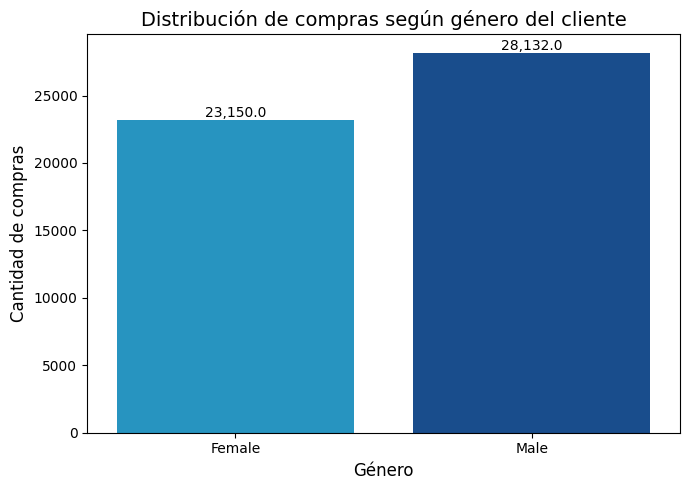

In [671]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))

palette = {
    'Female': custom_palette[3],  
    'Male': custom_palette[0]  
}

ax = sns.countplot(data=df, x='Gender', palette=palette)

plt.title('Distribución de compras según género del cliente', fontsize=14)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de compras', fontsize=12)

# Anotaciones

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

Este gráfico permite ver si hay un sesgo o tendencia por género en la base de clientes.


### Dispositivos


#### Ventas por tipo de dispositivo


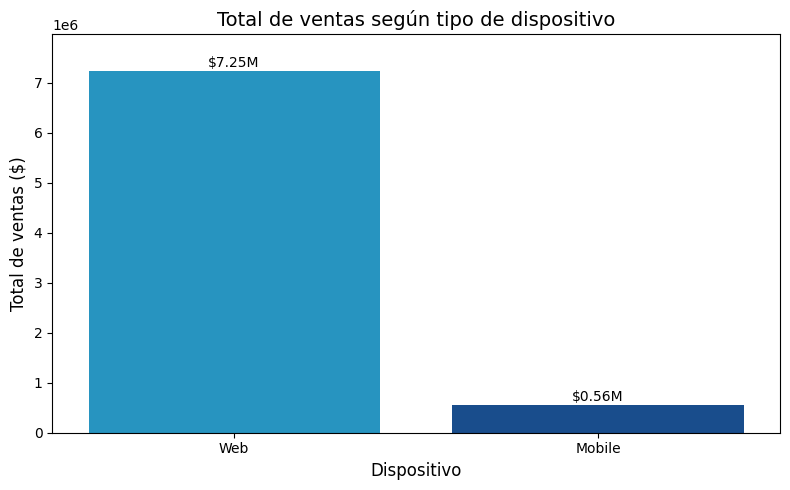

In [685]:
device_sales = df.groupby('Device_Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

palette = {'Web': custom_palette[3], 'Mobile': custom_palette[0] }

ax = sns.barplot(x=device_sales.index, y=device_sales.values, palette=palette)

plt.title('Total de ventas según tipo de dispositivo', fontsize=14)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Total de ventas ($)', fontsize=12)

# Anotaciones (en millones)
for i, (value, label) in enumerate(zip(device_sales.values, device_sales.index)):
    ax.text(i, value + device_sales.max() * 0.01, f'${value/1e6:.2f}M', ha='center', fontsize=10)

plt.ylim(0, device_sales.max() * 1.1)
plt.tight_layout()
plt.show()


Este gráfico permite identificar qué tipo de dispositivo genera mayor volumen de ventas. Esto puede guiar decisiones de optimización de la experiencia de usuario en cada canal.


In [686]:
device_behavior = df.groupby('Device_Type').agg({
    'Sales': 'mean',
    'Quantity': 'mean',
    'Customer_Id': 'count'
}).rename(columns={
    'Sales': 'Ticket Promedio',
    'Quantity': 'Unidades Promedio',
    'Customer_Id': 'Cantidad de Compras'
}).sort_values(by='Ticket Promedio', ascending=False)

device_behavior = device_behavior.reset_index()
device_behavior




,Device_Type,Ticket Promedio,Unidades Promedio,Cantidad de Compras
0,Mobile,154.002187,2.336249,3658
1,Web,152.209474,2.515769,47624


Esta tabla resume el comportamiento promedio por tipo de dispositivo:

- **Ticket Promedio**: cuánto gasta un usuario por compra.
- **Unidades Promedio**: cuántos productos compra por transacción.
- **Cantidad de Compras**: número total de operaciones por dispositivo.

Esto permite entender si hay diferencias importantes de comportamiento entre usuarios de desktop, mobile o tablet.


#### Distribución de compras por tipo de dispositivo


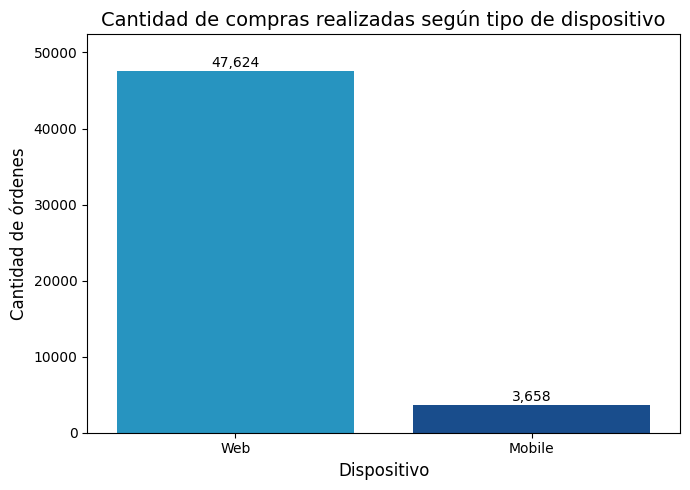

In [687]:
device_counts = df['Device_Type'].value_counts()

plt.figure(figsize=(7, 5))

# Paleta uniforme
palette = {'Web': custom_palette[3], 'Mobile': custom_palette[0] }

ax = sns.countplot(data=df, x='Device_Type', palette=palette, order=device_counts.index)

plt.title('Cantidad de compras realizadas según tipo de dispositivo', fontsize=14)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de órdenes', fontsize=12)

# Anotaciones encima de cada barra
for i, (value, label) in enumerate(zip(device_counts.values, device_counts.index)):
    ax.text(i, value + 500, f'{value:,}', ha='center', fontsize=10)

plt.ylim(0, device_counts.max() * 1.1)
plt.tight_layout()
plt.show()


Aunque algunos dispositivos pueden generar tickets más altos, otros pueden concentrar mayor volumen de transacciones. Esto puede guiar campañas según el canal.


### Logística y Entregas


#### Distribución de “Aging” (tiempo de entrega)


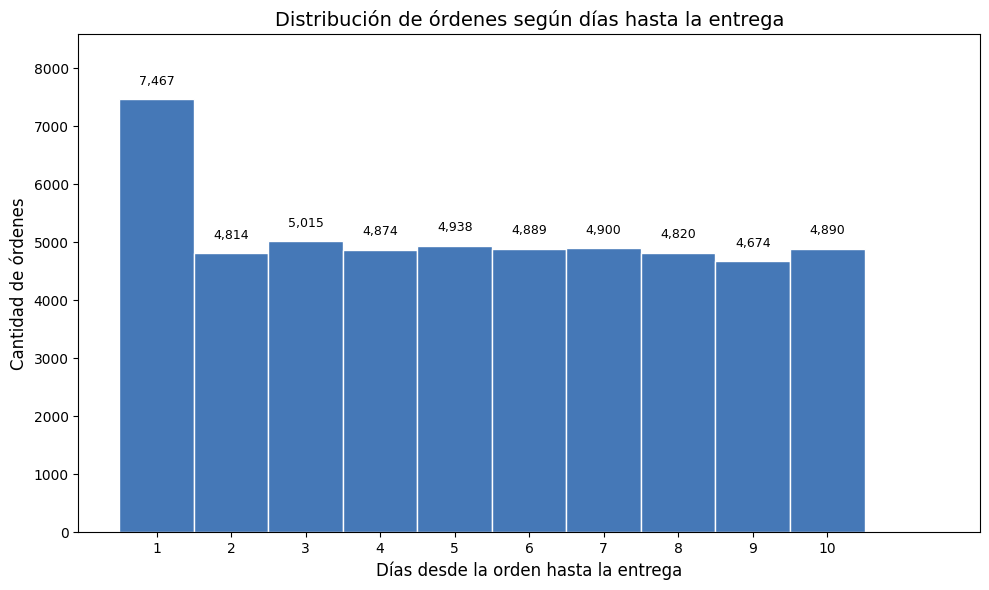

In [712]:
plt.figure(figsize=(10, 6))

# Histograma con estilo limpio y color plano
ax = sns.histplot(
    data=df,
    x='Aging',
    bins=range(1, 12),           # Días de 1 a 10
    discrete=True,               # Para datos enteros
    color=custom_palette[0],     # Elegí uno coherente con el resto
    edgecolor='white'            # Borde blanco para armonía visual
)

# Título y etiquetas
plt.title('Distribución de órdenes según días hasta la entrega', fontsize=14)
plt.xlabel('Días desde la orden hasta la entrega', fontsize=12)
plt.ylabel('Cantidad de órdenes', fontsize=12)

# Etiquetas arriba de las barras
for p in ax.patches:
    height = p.get_height()
    if height > 100:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 200,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Ajustes estéticos
plt.ylim(0, df['Aging'].value_counts().max() * 1.15)
plt.xticks(range(1, 11), fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()



Este gráfico muestra cómo se distribuye el tiempo de entrega. Una concentración en valores bajos indica una logística ágil; colas largas podrían señalar demoras.


#### Tiempo de entrega por mes


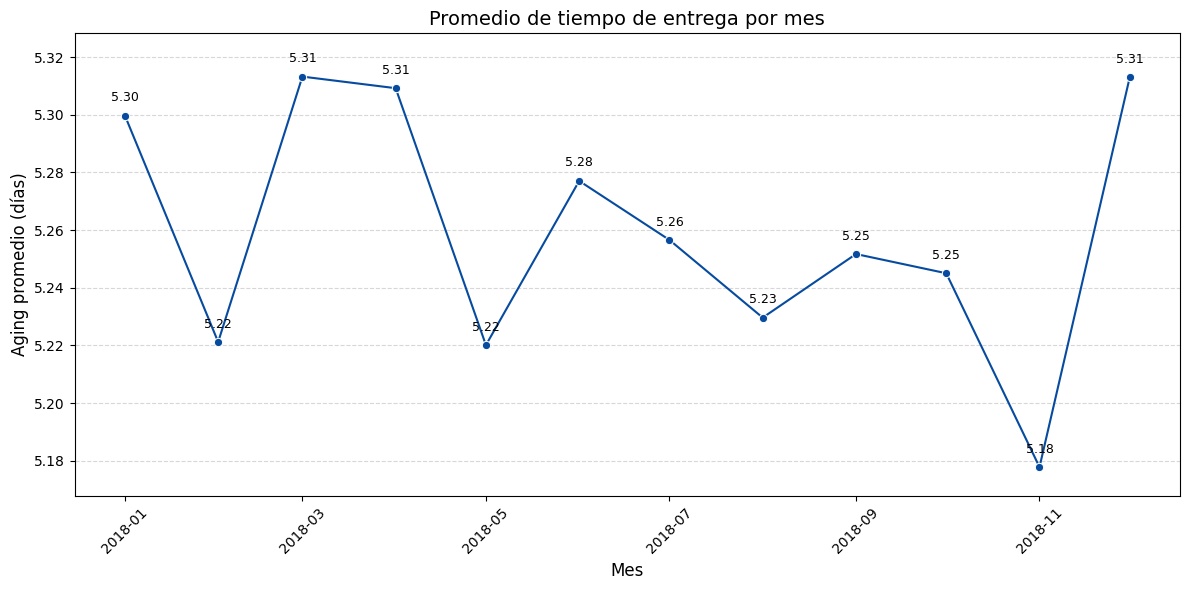

In [713]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
aging_by_month = df.groupby(df['Order_Date'].dt.to_period('M'))['Aging'].mean().reset_index()
aging_by_month['Order_Date'] = aging_by_month['Order_Date'].dt.to_timestamp()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=aging_by_month, x='Order_Date', y='Aging', marker='o', color=custom_palette[0])

plt.title('Promedio de tiempo de entrega por mes', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Aging promedio (días)', fontsize=12)
plt.xticks(rotation=45)

# Etiquetas en cada punto
for i, row in aging_by_month.iterrows():
    plt.text(row['Order_Date'], row['Aging'] + 0.005, f"{row['Aging']:.2f}", ha='center', fontsize=9)

plt.ylim(aging_by_month['Aging'].min() - 0.01, aging_by_month['Aging'].max() + 0.015)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Esto permite ver si la eficiencia logística ha mejorado o empeorado a lo largo del tiempo.


### Tiempo de entrega por categoría


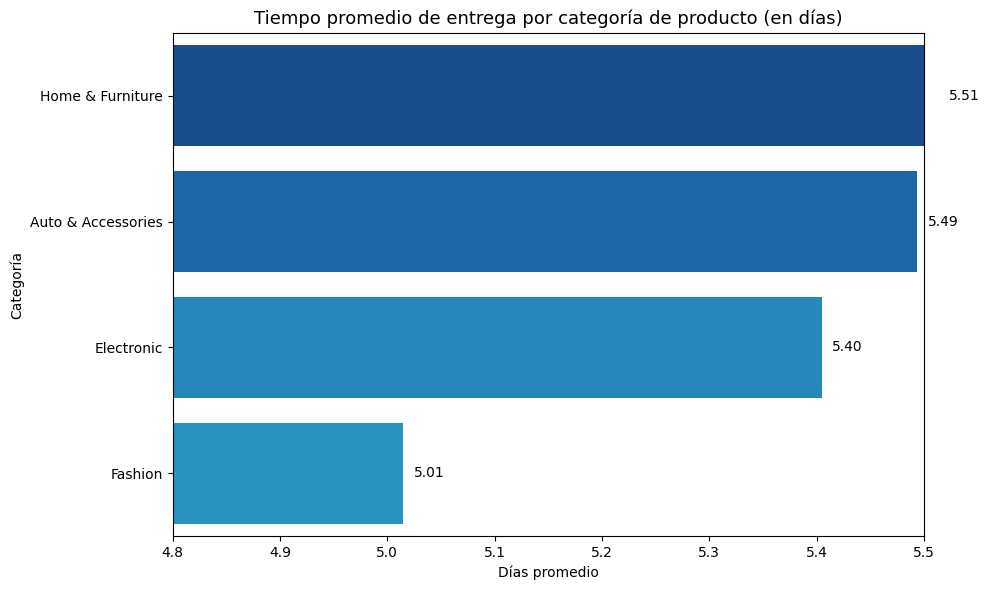

In [714]:
aging_by_cat = df.groupby('Product_Category')['Aging'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=aging_by_cat.values, y=aging_by_cat.index, palette=custom_palette)

plt.title('Tiempo promedio de entrega por categoría de producto (en días)', fontsize=13)
plt.xlabel('Días promedio')
plt.ylabel('Categoría')
plt.xlim(4.8, 5.5)  # opcional, si los valores son todos cercanos

# Anotar valores en las barras
for i, (value, label) in enumerate(zip(aging_by_cat.values, aging_by_cat.index)):
    ax.text(value + 0.01, i, f'{value:.2f}', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


Algunas categorías podrían tener tiempos de entrega más largos debido a disponibilidad, logística especial o stock limitado.
